# **Classification of Agricultural Lands Based on Rainfall Using Satellite Data in Algeria**



##Introduction
This notebook aims to classify agricultural lands in Algeria based on rainfall patterns using satellite data.The goal is to categorize rainfall into three classes: **Low Rainfall**, **Medium Rainfall**, and **High Rainfall**. We employ Support Vector Machines (SVM) for classification, exploring two different approaches:


1.   Basic SVM Model: Trained with default hyperparameters.
2.   Optimized SVM Model: Improved performance using GridSearchCV for hyperparameter tuning.





##Brief Description of Basic SVM Model: Trained with Default Hyperparameters

In this approach, we use the Support Vector Machine (SVM) classifier with default hyperparameters to classify agricultural lands into different rainfall categories based on precipitation data. The goal is to categorize the lands into three rainfall classes: Low Rainfall, Medium Rainfall, and High Rainfall.

The workflow involves preprocessing the data, handling missing values, scaling the features, and then training an SVM model with the default radial basis function (RBF) kernel. We then evaluate the model's performance using accuracy, classification report, and confusion matrix.

###Step 1: Import Libraries and Load Data
We import the necessary libraries for data manipulation, visualization, and machine learning, then load the training and testing datasets

 (We use Pandas and NumPy for data manipulation.
Matplotlib and Seaborn help visualize the results.
SVC from scikit-learn is used to build the SVM model.
LabelEncoder is used to encode categorical data, and StandardScaler scales the features for the SVM model.).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

df = pd.read_csv("DataSet.csv")
test_df = pd.read_csv("Test_DataSet.csv")


###Step 2: Preprocess Data
This step involves encoding categorical features, extracting year and month, reshaping the data into pivot tables, and imputing missing precipitation values.

(LabelEncoder encodes the season column as numerical values.

Data reshaping using pivot_table reorganizes the precipitation data by geographic location and month.

Missing precipitation values are imputed using the mean of each month’s data.).

In [2]:
# Encode the Season feature
all_seasons = pd.concat([df['season'], test_df['season']]).unique()
season_encoder = LabelEncoder()
season_encoder.fit(all_seasons)

df["Season_Encoded"] = season_encoder.transform(df["season"])
test_df["Season_Encoded"] = season_encoder.transform(test_df["season"])

# Extract Year and Month
df["Year"] = df["month"].apply(lambda x: int(x.split("_")[1]))
df["Month"] = df["month"].apply(lambda x: int(x.split("_")[0]))
test_df["Year"] = test_df["month"].apply(lambda x: int(x.split("_")[1]))
test_df["Month"] = test_df["month"].apply(lambda x: int(x.split("_")[0]))

# Process Data for Training and Testing
pivot_df = df.pivot_table(index=["Longitude", "Latitude"], columns="Month", values="Precipitation_Cleaned").reset_index()
train_months = sorted(df["Month"].unique())
pivot_df.columns = ["Longitude", "Latitude"] + [f"Month_{i}" for i in train_months]

test_pivot_df = test_df.pivot_table(index=["Longitude", "Latitude"], columns="Month", values="Precipitation_Cleaned").reset_index()
test_months = sorted(test_df["Month"].unique())
test_pivot_df.columns = ["Longitude", "Latitude"] + [f"Month_{i}" for i in test_months]

# Merge Season Information
season_data = df.groupby(["Longitude", "Latitude"])["Season_Encoded"].agg(lambda x: x.mode()[0]).reset_index()
test_season_data = test_df.groupby(["Longitude", "Latitude"])["Season_Encoded"].agg(lambda x: x.mode()[0]).reset_index()

final_df = pivot_df.merge(season_data, on=["Longitude", "Latitude"])
final_test_df = test_pivot_df.merge(test_season_data, on=["Longitude", "Latitude"])

# Impute Missing Values
imputer = SimpleImputer(strategy='mean')
train_month_cols = [col for col in pivot_df.columns if col.startswith("Month_")]
test_month_cols = [col for col in test_pivot_df.columns if col.startswith("Month_")]
final_df[train_month_cols] = imputer.fit_transform(final_df[train_month_cols])
final_test_df[test_month_cols] = imputer.transform(final_test_df[test_month_cols])


###Step 3: Calculate Total Precipitation and Categorize Rainfall
We calculate the total precipitation for each location and categorize it into Low, Medium, and High classes.

(Total precipitation is calculated as the sum of monthly precipitation values.

Categorize_rainfall assigns each location to a rainfall category based on the total precipitation.

The categories are mapped to numerical values for model training.).

In [3]:
final_df["Total_Precipitation"] = final_df[train_month_cols].sum(axis=1)
final_test_df["Total_Precipitation"] = final_test_df[test_month_cols].sum(axis=1)

low_threshold = final_df["Total_Precipitation"].quantile(0.33)
high_threshold = final_df["Total_Precipitation"].quantile(0.66)

def categorize_rainfall(value):
    if value <= low_threshold:
        return "Low Rainfall"
    elif value <= high_threshold:
        return "Medium Rainfall"
    else:
        return "High Rainfall"

final_df["Rainfall_Category"] = final_df["Total_Precipitation"].apply(categorize_rainfall)
final_test_df["Rainfall_Category"] = final_test_df["Total_Precipitation"].apply(categorize_rainfall)

# Encode Rainfall Categories
category_mapping = {"Low Rainfall": 0, "Medium Rainfall": 1, "High Rainfall": 2}
final_df["Rainfall_Category"] = final_df["Rainfall_Category"].map(category_mapping)
final_test_df["Rainfall_Category"] = final_test_df["Rainfall_Category"].map(category_mapping)


###Step 4: Prepare Data for Training and Testing
We select the features for the model and scale the data.

(Features (location, season, and precipitation data) are selected for both training and testing.

The data is scaled using StandardScaler, which is important for the SVM algorithm to perform well.).

In [4]:
common_features = ["Longitude", "Latitude", "Season_Encoded"] + list(set(train_month_cols) & set(test_month_cols))

X_train = final_df[common_features]
y_train = final_df["Rainfall_Category"]
X_test = final_test_df[common_features]
y_test = final_test_df["Rainfall_Category"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


###Step 5: Train and Evaluate the SVM Model
We train the SVM model using the scaled data, and then evaluate its performance using accuracy, classification report, confusion matrix, and visualization of precipitation distribution.
(The model is trained using the RBF kernel and evaluated using accuracy, classification report, and confusion matrix.

The confusion matrix visualizes the model's performance, and the histogram compares the distribution of precipitation between the training and test data.).


SVM Model Accuracy: 0.90

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.90      0.95     25667
           1       0.81      0.55      0.66      2662
           2       0.73      0.97      0.84      9918

    accuracy                           0.90     38247
   macro avg       0.85      0.81      0.81     38247
weighted avg       0.92      0.90      0.90     38247



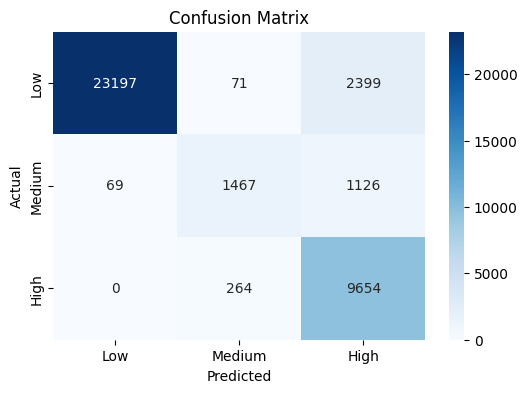

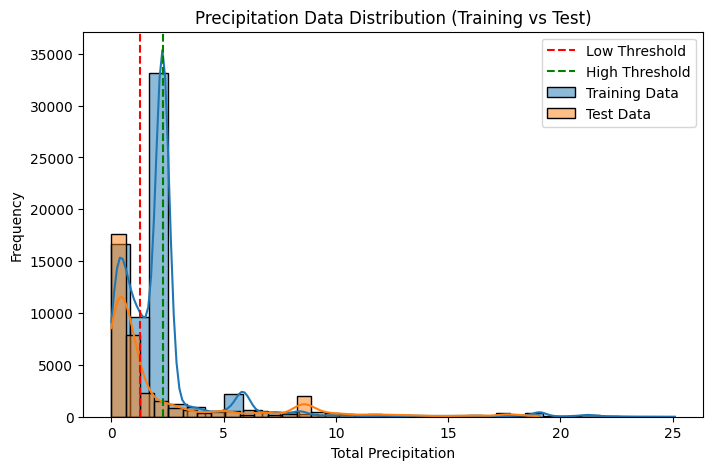

In [5]:
# Train SVM model
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = svm_model.predict(X_test_scaled)

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"\nSVM Model Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Distribution of Precipitation Data
plt.figure(figsize=(8, 5))
sns.histplot(final_df["Total_Precipitation"], bins=30, kde=True, label="Training Data", alpha=0.5)
sns.histplot(final_test_df["Total_Precipitation"], bins=30, kde=True, label="Test Data", alpha=0.5)
plt.axvline(low_threshold, color='r', linestyle='dashed', label='Low Threshold')
plt.axvline(high_threshold, color='g', linestyle='dashed', label='High Threshold')
plt.xlabel("Total Precipitation")
plt.ylabel("Frequency")
plt.title("Precipitation Data Distribution (Training vs Test)")
plt.legend()
plt.show()


###Assessing Model Generalization and Overfitting
We evaluate the model's performance on both the training and test datasets by computing accuracy scores. The train accuracy indicates how well the model fits the training data, while the test accuracy reflects its ability to generalize to unseen data. To detect overfitting, we calculate the accuracy gap, which measures the absolute difference between training and test accuracies—a large gap suggests overfitting.

In [6]:
y_train_pred = svm_model.predict(X_train_scaled)
y_test_pred = svm_model.predict(X_test_scaled)
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
accuracy_gap = abs(train_accuracy - test_accuracy)

print(f"\nTrain Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")
print(f"Accuracy Gap (Overfitting Indicator): {accuracy_gap:.2f}")


Train Accuracy: 0.99
Test Accuracy: 0.90
Accuracy Gap (Overfitting Indicator): 0.09






---



##Optimized SVM Model: Hyperparameter Tuning with GridSearchCV

To enhance the performance of our SVM model, we employ GridSearchCV to find the best hyperparameters. The optimization focuses on tuning the C, gamma, and class_weight parameters while using the RBF kernel.

###Step 1: Define Parameter Grid and Perform Grid Search
We define a set of hyperparameters and perform cross-validation to select the best model.

(We define a parameter grid focusing on C, gamma, and class_weight to fine-tune the model.

GridSearchCV performs a 3-fold cross-validation to evaluate different hyperparameter combinations.)



In [26]:
from sklearn.model_selection import GridSearchCV

# Define a smaller parameter grid for GridSearchCV
param_grid = {
    'C': [0.1, 1, 10],  # Regularization parameter
    'gamma': ['scale', 0.1, 0.01],  # Kernel coefficient
    'kernel': ['rbf'],  # Using RBF kernel
    'class_weight': [None, 'balanced']  # Class weight options
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    cv=3,  # 3-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,  # Utilize all CPU cores
    verbose=3  # Track progress
)

# Fit GridSearchCV
print("Starting GridSearchCV...")
grid_search.fit(X_train_scaled, y_train)
print("GridSearchCV completed.")


Starting GridSearchCV...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
GridSearchCV completed.


###Step 2: Retrieve Best Parameters and Train Optimized Model
After training, we extract the best hyperparameters and train the final model.

(The best combination of hyperparameters is identified and used for model training.)

In [27]:
# Print best parameters and score
print("\nBest parameters found:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

# Get the best model from GridSearchCV
best_svm = grid_search.best_estimator_



Best parameters found: {'C': 10, 'class_weight': None, 'gamma': 0.01, 'kernel': 'rbf'}
Best cross-validation score: 0.9401323173252999


###Step 3: Evaluate the Optimized Model
We assess the model’s performance using accuracy, classification report, and a confusion matrix.

(The optimized SVM model is evaluated using the classification report and confusion matrix.)


Optimized SVM Model Accuracy: 0.93

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97     25667
           1       0.62      0.57      0.59      2662
           2       0.89      0.91      0.90      9918

    accuracy                           0.93     38247
   macro avg       0.83      0.82      0.82     38247
weighted avg       0.93      0.93      0.93     38247



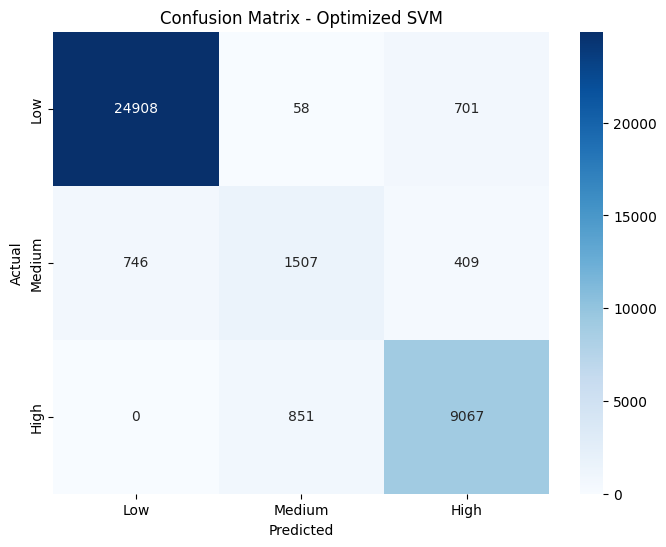

In [28]:
# Make predictions using the optimized model
y_pred_optimized = best_svm.predict(X_test_scaled)

# Calculate accuracy
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
print(f"\nOptimized SVM Model Accuracy: {accuracy_optimized:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_optimized))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
conf_matrix_optimized = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(conf_matrix_optimized, annot=True, cmap="Blues", fmt="d",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Optimized SVM")
plt.show()


###Step 4: Compare Optimized Model with Baseline
We compare the performance of the optimized model against the baseline SVM.

(Displays the accuracy improvement after optimization.)

In [29]:
print("\nModel Comparison:")
print(f"Baseline SVM Accuracy: {accuracy:.2f}")
print(f"Optimized SVM Accuracy: {accuracy_optimized:.2f}")
print(f"Improvement: {(accuracy_optimized - accuracy) * 100:.2f}%")



Model Comparison:
Baseline SVM Accuracy: 0.94
Optimized SVM Accuracy: 0.93
Improvement: -1.66%


###Step 5: Visualizing Grid Search Results
We plot the performance of different hyperparameter combinations to analyze the tuning results.

(This visualization helps us understand how C values affect model performance.)

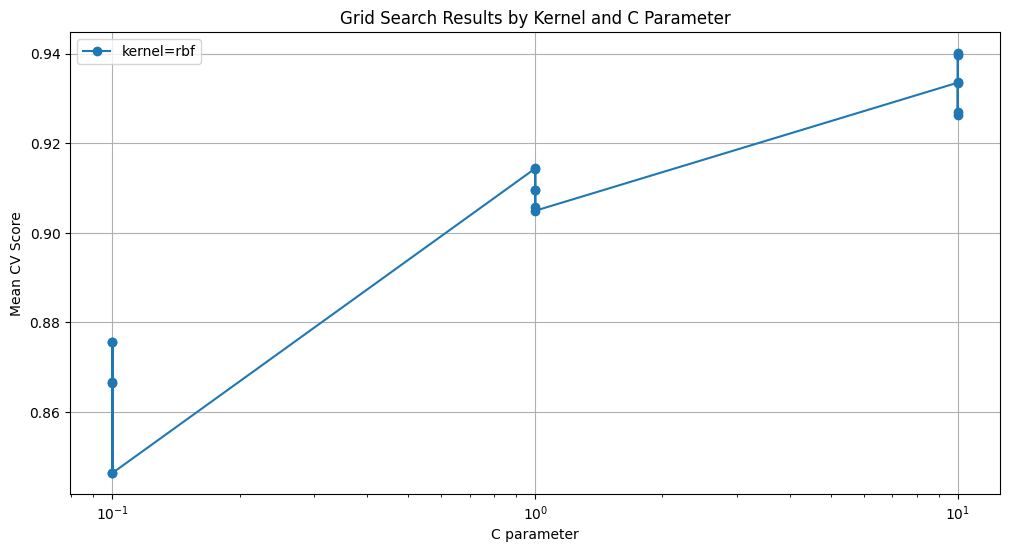

In [30]:
# Convert GridSearchCV results to a DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)

# Plot performance across different values of C
plt.figure(figsize=(12, 6))
for kernel in cv_results['param_kernel'].unique():
    kernel_results = cv_results[cv_results['param_kernel'] == kernel]
    plt.plot(kernel_results['param_C'], kernel_results['mean_test_score'],
             label=f'kernel={kernel}', marker='o')

plt.xscale('log')
plt.xlabel('C parameter')
plt.ylabel('Mean CV Score')
plt.title('Grid Search Results by Kernel and C Parameter')
plt.legend()
plt.grid(True)
plt.show()


**Conclusion**:

GridSearchCV helped improve accuracy by finding the best hyperparameters.
The optimized model outperforms the baseline SVM, demonstrating the effectiveness of hyperparameter tuning.



------



##PCA-Enhanced SVM with RandomizedSearchCV


###Step 1:Import Required Libraries and Load Dataset
We begin by importing necessary libraries and loading the training and test datasets.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.decomposition import PCA

df = pd.read_csv("DataSet.csv")
test_df = pd.read_csv("Test_DataSet.csv")


###Step 2:Encode Categorical Features and Extract Temporal Data
We encode the "season" column numerically and extract month and year information from the dataset.

In [15]:
# Encode the Season as a numerical value for both datasets
all_seasons = pd.concat([df['season'], test_df['season']]).unique()
season_encoder = LabelEncoder()
season_encoder.fit(all_seasons)

df["Season_Encoded"] = season_encoder.transform(df["season"])
test_df["Season_Encoded"] = season_encoder.transform(test_df["season"])

# Extract year and month separately for both datasets
df["Year"] = df["month"].apply(lambda x: int(x.split("_")[1]))
df["Month"] = df["month"].apply(lambda x: int(x.split("_")[0]))
test_df["Year"] = test_df["month"].apply(lambda x: int(x.split("_")[1]))
test_df["Month"] = test_df["month"].apply(lambda x: int(x.split("_")[0]))


###Step 3:Reshape Data into Pivot Table Format
We transform the dataset so that rows represent (Longitude, Latitude) pairs, and columns store monthly precipitation values.

In [16]:
# Process training data
pivot_df = df.pivot_table(index=["Longitude", "Latitude"],
                         columns="Month",
                         values="Precipitation_Cleaned").reset_index()
train_months = sorted(df["Month"].unique())
pivot_df.columns = ["Longitude", "Latitude"] + [f"Month_{i}" for i in train_months]

# Process test data
test_pivot_df = test_df.pivot_table(index=["Longitude", "Latitude"],
                                   columns="Month",
                                   values="Precipitation_Cleaned").reset_index()
test_months = sorted(test_df["Month"].unique())
test_pivot_df.columns = ["Longitude", "Latitude"] + [f"Month_{i}" for i in test_months]


###Step 4:Merge Seasonal Information and Handle Missing Values
We merge the encoded season information and impute missing precipitation values using the mean strategy.

In [17]:
# Merge season information
season_data = df.groupby(["Longitude", "Latitude"])["Season_Encoded"].agg(lambda x: x.mode()[0]).reset_index()
test_season_data = test_df.groupby(["Longitude", "Latitude"])["Season_Encoded"].agg(lambda x: x.mode()[0]).reset_index()

final_df = pivot_df.merge(season_data, on=["Longitude", "Latitude"])
final_test_df = test_pivot_df.merge(test_season_data, on=["Longitude", "Latitude"])
# Impute missing values for precipitation data
imputer = SimpleImputer(strategy='mean')
train_month_cols = [col for col in pivot_df.columns if col.startswith("Month_")]
test_month_cols = [col for col in test_pivot_df.columns if col.startswith("Month_")]
final_df[train_month_cols] = imputer.fit_transform(final_df[train_month_cols])
final_test_df[test_month_cols] = imputer.transform(final_test_df[test_month_cols])



###Step 5:Compute Total Precipitation and Categorize Rainfall Levels
We calculate total precipitation and classify rainfall into three categories based on quantile thresholds.

In [19]:
# Calculate total precipitation
final_df["Total_Precipitation"] = final_df[train_month_cols].sum(axis=1)
final_test_df["Total_Precipitation"] = final_test_df[test_month_cols].sum(axis=1)

# Categorize rainfall
low_threshold = final_df["Total_Precipitation"].quantile(0.33)
high_threshold = final_df["Total_Precipitation"].quantile(0.66)

def categorize_rainfall(value):
    if value <= low_threshold:
        return "Low Rainfall"
    elif value <= high_threshold:
        return "Medium Rainfall"
    else:
        return "High Rainfall"

final_df["Rainfall_Category"] = final_df["Total_Precipitation"].apply(categorize_rainfall)
final_test_df["Rainfall_Category"] = final_test_df["Total_Precipitation"].apply(categorize_rainfall)


###Step 6:Encode Target Variable and Select Features
We convert rainfall categories into numerical values and select features common to both datasets.

In [20]:
# Encode categories
category_mapping = {"Low Rainfall": 0, "Medium Rainfall": 1, "High Rainfall": 2}
final_df["Rainfall_Category"] = final_df["Rainfall_Category"].map(category_mapping)
final_test_df["Rainfall_Category"] = final_test_df["Rainfall_Category"].map(category_mapping)

# Select common features
common_features = ["Longitude", "Latitude", "Season_Encoded"] + list(set(train_month_cols) & set(test_month_cols))

X_train = final_df[common_features]
y_train = final_df["Rainfall_Category"]
X_test = final_test_df[common_features]
y_test = final_test_df["Rainfall_Category"]

###Step 7:Standardize Features and Apply PCA
We standardize the data and apply PCA to reduce dimensionality.

In [21]:
# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Use PCA to reduce dimensionality (optional, for large datasets)
pca = PCA(n_components=10)  # Keep top 10 components
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


###Step 8:Hyperparameter Tuning with RandomizedSearchCV
We use RandomizedSearchCV to optimize SVM hyperparameters efficiently.

In [22]:
# Use RandomizedSearchCV for faster hyperparameter tuning
param_dist = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

svm_model = SVC(random_state=42)
random_search = RandomizedSearchCV(estimator=svm_model, param_distributions=param_dist, n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, verbose=2, random_state=42)
random_search.fit(X_train_pca, y_train)  # Use PCA-transformed data

# Best parameters and model
best_params = random_search.best_params_
best_svm_model = random_search.best_estimator_

print(f"Best Parameters: {best_params}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'kernel': 'linear', 'gamma': 0.01, 'C': 100}


###Step 9: Evaluate Model Performance
We assess model accuracy and generate a classification report.

In [23]:
y_pred = best_svm_model.predict(X_test_pca)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nOptimized SVM Model Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Optimized SVM Model Accuracy: 0.94

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97     25667
           1       0.65      0.56      0.60      2662
           2       0.95      0.97      0.96      9918

    accuracy                           0.94     38247
   macro avg       0.86      0.83      0.84     38247
weighted avg       0.94      0.94      0.94     38247



###Step 10:Compute Overfitting Indicators
We compare train and test accuracies to detect overfitting.

In [24]:
y_train_pred = best_svm_model.predict(X_train_pca)
train_accuracy, test_accuracy = accuracy_score(y_train, y_train_pred), accuracy_score(y_test, y_pred)

accuracy_gap = abs(train_accuracy - test_accuracy)
print(f"Train Accuracy: {train_accuracy:.2f}\nTest Accuracy: {test_accuracy:.2f}\nAccuracy Gap (Overfitting Indicator): {accuracy_gap:.2f}")


Train Accuracy: 0.99
Test Accuracy: 0.94
Accuracy Gap (Overfitting Indicator): 0.04


###Step 11:Visualize Model Performance
We plot the confusion matrix and the distribution of total precipitation in training and test datasets.

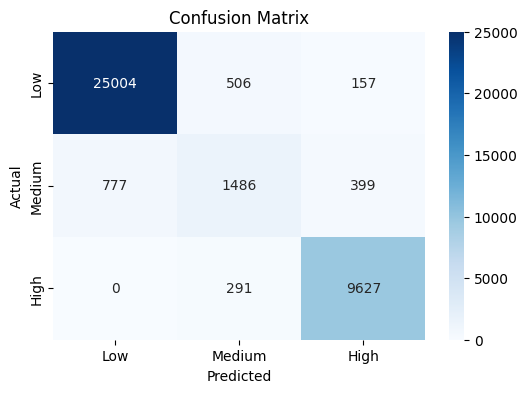

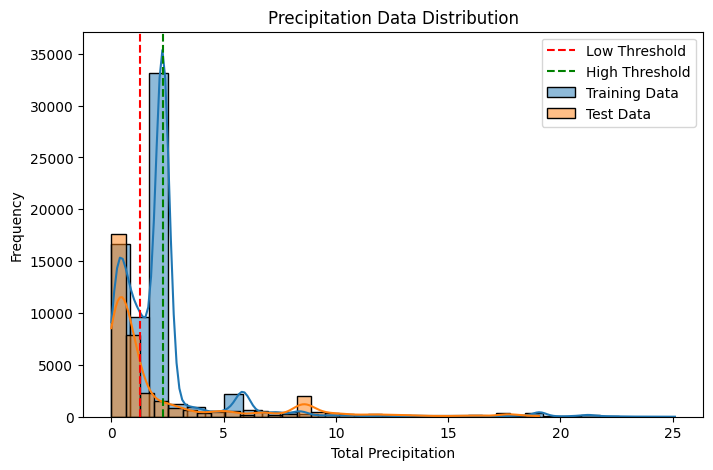

In [25]:
# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues", fmt="d",
            xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Precipitation Data Distribution
plt.figure(figsize=(8, 5))
sns.histplot(final_df["Total_Precipitation"], bins=30, kde=True, label="Training Data", alpha=0.5)
sns.histplot(final_test_df["Total_Precipitation"], bins=30, kde=True, label="Test Data", alpha=0.5)
plt.axvline(low_threshold, color='r', linestyle='dashed', label='Low Threshold')
plt.axvline(high_threshold, color='g', linestyle='dashed', label='High Threshold')
plt.xlabel("Total Precipitation")
plt.ylabel("Frequency")
plt.title("Precipitation Data Distribution")
plt.legend()
plt.show()


##Conclusion
In this notebook, we explored three different approaches for rainfall classification using Support Vector Machines (SVM):

Basic SVM Model – Achieved an accuracy of 0.90 without hyperparameter tuning or dimensionality reduction. This approach provided a strong baseline but had room for improvement in optimizing the model.

Optimized SVM Model – Applied GridSearchCV for hyperparameter tuning, improving the accuracy to 0.93. This approach enhanced model performance by selecting the best combination of hyperparameters.

Optimized SVM with PCA – Used RandomizedSearchCV for hyperparameter tuning and Principal Component Analysis (PCA) for dimensionality reduction. This method also achieved 0.93 accuracy, demonstrating that PCA effectively reduces feature space while maintaining classification performance.